In [ ]:
#####################
#  FWHM ESTIMATION  #
#####################

# This routine contains two methods to have an estimate of the fwhm of a fits image.
# First method uses Photutils > Aperturestats built-in function and it also subrtacts background from a region around the star
# Second code snippet extracts a specific region (psf) from the image data as the input. returns a 2D Gaussian function,
# provides a simple way to estimate the key properties (centroid and size) of a
# 2D object in an image based on its pixel intensities. Estimate background using an annulus Calculate FWHM

In [21]:
#### Method1: Photutils > Aperturestats
# Measuring FWHM Method 1: Using Photutils ApertureStats
# Make sure to define the position of the star precisely
# First not removing background
from photutils.background import Background2D
from photutils.aperture import ApertureStats
import numpy as np
from astropy.io import fits
from astropy.nddata import CCDData
from photutils.aperture import CircularAperture, ApertureStats
#Specify the location of a star in the "light_frame_name" image and place a circle with the specified radius around it
aper = CircularAperture((2097,1925), 40)

aperstats = ApertureStats(flatanddark, aper)
print(f"FWHM in pixels: {aperstats.fwhm:.2f}")  
pixel_scale = 0.0439  # arcseconds/pixel - found from 3 arcminutes divided by 4096
fwhm_arcsec = aperstats.fwhm * pixel_scale
print(f"Seeing in arcseconds: {fwhm_arcsec:.2f}")

FWHM in pixels: 47.20 pix
Seeing in arcseconds: 2.07 pix


In [22]:
#Second with removing background

# Replace with the actual file path
file_path = "C:\\Users\\Observatory\\Exo\\Data\\" \
             "HAT-P32b-15Oct2024-low\\calibrated\\" \
             "HAT-9-32b-g_2024_10_15_exp00.00.30.000_1x1_Low_1_calibrated_darkandflat.fits"
# Read the FITS file
with fits.open(file_path) as hdul:
    data = hdul[0].data  # Assuming the data is in the first extension

# Create a CCDData object 
flatanddark = CCDData(data, unit='adu') 
# Rest of the code remains the same
aper = CircularAperture((2146, 1999), 40)
bkg_estimator = Background2D(flatanddark, (120, 120))
bkg = bkg_estimator.background 
data_subtracted = flatanddark - bkg 
aperstats = ApertureStats(data_subtracted, aper) 

print(f"FWHM in pixels: {aperstats.fwhm:.2f}") 
pixel_scale = 0.0439  # arcseconds/pixel
fwhm_arcsec = aperstats.fwhm * pixel_scale
print(f"Seeing in arcseconds: {fwhm_arcsec:.2f}")


FWHM in pixels: 35.83 pix
Seeing in arcseconds: 1.57 pix


FWHM x: 34.63 pixels, FWHM y: 34.98 pixels
Average FWHM: 34.81 pixels
Seeing: 1.53 arcseconds


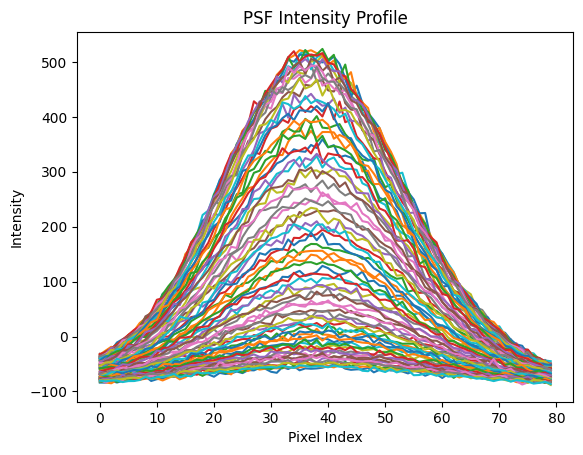

In [23]:
#### Method2: Gaussian estimation

import numpy as np
import math
from scipy import optimize
from astropy.io import fits
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d

# This creates and returns a 2D Gaussian function.The returned lambda function is a “callable” 
# object; you can use it later to evaluate the Gaussian at various (x, y) points.
def gaussian(height, center_x, center_y, width_x, width_y):
	"""Returns a gaussian function with the given parameters"""
	width_x = float(width_x)
	width_y = float(width_y)
	return lambda x,y: height*np.exp(-(((center_x-x)/width_x)**2+((center_y-y)/width_y)**2)/2)


# This function provides a simple way to estimate the key properties (centroid and size) of a
# 2D object in an image based on its pixel intensities.
def moments(kata):
    try:
        total = kata.sum()
        X, Y = np.indices(kata.shape)
        x = (X * kata).sum() / total
        y = (Y * kata).sum() / total
        col = kata[:, int(y)]
        width_x = np.sqrt(np.abs((np.arange(col.size) - y) ** 2 * col).sum() / col.sum())
        row = kata[int(x), :]
        width_y = np.sqrt(np.abs((np.arange(row.size) - x) ** 2 * row).sum() / row.sum())
        height = kata.max()
        return height, x, y, width_x, width_y
    except (ValueError, TypeError, ZeroDivisionError) as e:
        print(f"Error in moments function: {e}")
        return None
        
# this function improves the accuracy of the Gaussian parameter estimation by using a non-linear least-squares method 
# to fit a 2D Gaussian to the input data, using the moment-based estimates as a starting point. The result is a more 
# precise determination of the Gaussian’s parameters than what moments alone could provide. 
def fitgaussian(kata):
    """Returns (height, x, y, width_x, width_y)
    the gaussian parameters of a 2D distribution found by a fit"""
    params = moments(kata)
    errorfunction = lambda p: np.ravel(gaussian(*p)(*np.indices(kata.shape)) - kata)
    p, success = optimize.leastsq(errorfunction, params)
    return p

try:
    image = np.array(flatanddark)

    # Define star center and aperture size
    star_center = (2146, 1999) 
    aperture_radius = 40 

    # Extract region around star
    x_min, x_max = int(star_center[0] - aperture_radius), int(star_center[0] + aperture_radius)
    y_min, y_max = int(star_center[1] - aperture_radius), int(star_center[1] + aperture_radius)
    psf_region = image[y_min:y_max, x_min:x_max]

    # Estimate background using an annulus
    inner_radius = aperture_radius // 2 
    outer_radius = aperture_radius
    annulus_mask = (np.sqrt((np.arange(psf_region.shape[0])[:, np.newaxis] - psf_region.shape[0] // 2)**2 + 
                             (np.arange(psf_region.shape[1]) - psf_region.shape[1] // 2)**2) 
                    >= inner_radius) & (np.sqrt((np.arange(psf_region.shape[0])[:, np.newaxis] - psf_region.shape[0] // 2)**2 + 
                                               (np.arange(psf_region.shape[1]) - psf_region.shape[1] // 2)**2) 
                    <= outer_radius)
    background_value = np.median(psf_region[annulus_mask])

    # Subtract background
    psf = psf_region - background_value 

    # Calculate FWHM
    result = moments(psf)
    if result:
        width_x, width_y = result[3], result[4]
        fwhm_x = 2 * np.sqrt(2 * np.log(2)) * width_x
        fwhm_y = 2 * np.sqrt(2 * np.log(2)) * width_y
        avg_fwhm_pixels = (fwhm_x + fwhm_y) / 2.0
        pixel_scale = 0.0439  # arcseconds/pixel
        seeing_arcsec = avg_fwhm_pixels * pixel_scale

        print(f"FWHM x: {fwhm_x:.2f} pixels, FWHM y: {fwhm_y:.2f} pixels")
        print(f"Average FWHM: {avg_fwhm_pixels:.2f} pixels")
        print(f"Seeing: {seeing_arcsec:.2f} arcseconds")

        fig = plt.figure()
        plt.plot(psf)
        plt.title('PSF Intensity Profile') 
        plt.xlabel('Pixel Index') 
        plt.ylabel('Intensity') 
        plt.show()
    else:
        print("Moments calculation failed.")
    
except Exception as e:
    print(f"An error occurred: {e}")
    


In [ ]:
# Well the results I am getting out of these two codes are generally higher than what the MaximDL program 
# reads. Generally by a value of around 4 to 6